# SETUP: `Iceland2_MARBL_2024`

This notebook configures the high-resolution regional grid and forcing for the Iceland2_MARBL_2024 configuration.

- **Grid generation/import**: Build or load the EMOD-based child grid and inspect vertical coordinates.
- **Tides**: Create TPXO tidal forcing on the Iceland2 grid.
- **Initial conditions**: Interpolate from the parent Iceland1 ROMS restart (physics + BGC).
- **Surface forcing**: Generate ERA5-based physics and UNIFIED BGC surface climatologies for 2024.
- **Child (Iceland3)**: Define the nested fjord-scale grid and write its grid and nesting files.
- **Rivers**: Build and customize river forcing (volume and BGC tracers) for Hvalfjörður.

Run cells in order when regenerating Iceland2 input files or updating river/BGC assumptions.

# ROMS-TOOLS setup for Iceland2_MARBL_2024

First step is to set up the outer grid using ROMS-TOOLS and save the grid file.

In [1]:
from roms_tools import Grid

/home/x-uheede/.conda/envs/romstools-test/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
project='/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/'
datasets='/anvil/projects/x-ees250129/Datasets/'
model_name='Iceland2'
child_name='Iceland3'
grid_path='/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_grid.nc'

CPU times: user 27min 59s, sys: 4.14 s, total: 28min 4s
Wall time: 31.7 s


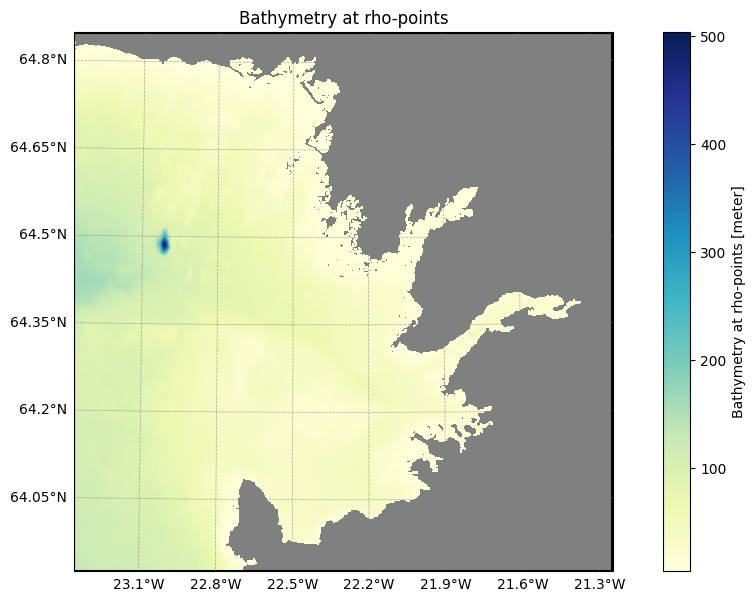

In [5]:
%%time

grid = Grid(
    nx=512,
    ny=512,
    size_x=102.4,
    size_y=102.4,
    center_lon=-22.3,
    center_lat=64.39,
    rot=0,
    mask_shapefile=datasets+"GSHHS/gshhg-shp-2.3.7/GSHHS_shp/f/GSHHS_f_L1.shp",
    close_narrow_channels=True,
    topography_source={
        "name": "EMOD",
        "path": datasets+"EMODnet_C2.nc"},
    N=60  # number of vertical layers
)

grid.plot()

In [10]:
#import sys
#sys.path.append("/anvil/projects/x-ees250129/x-uheede/fill_narrows")

#import fill_narrow

## After grid creation, you can fill narrow passages
#grid.ds = fill_narrow.fill_narrow_passages(
#    grid.ds,
#    mask_var="mask_rho",
#    max_iterations=10,
#    )

#grid.plot()

In [11]:
grid = Grid.from_file(grid_path)
#grid.update_vertical_coordinate(N=60, theta_s=5.0, theta_b=2.0, hc=300.0, verbose=False)
#grid.plot()

In [12]:
filepath = project+model_name+'_grid.nc'

In [ ]:
grid.plot_vertical_coordinate(eta=250, max_nr_layer_contours=10,)

In [ ]:
grid.plot_vertical_coordinate(eta=250, max_nr_layer_contours=10,)

In [ ]:
#grid.save(filepath)

In [ ]:
tpxo_path = datasets+"TPXO/TPXO10.v2/"
tpxo_dict = {
    "grid": tpxo_path + "grid_tpxo10v2.nc",
    "h": tpxo_path + "h_tpxo10.v2.nc",
    "u": tpxo_path + "u_tpxo10.v2.nc",
}

Next, we set up tidal forcing:

In [ ]:
from roms_tools import TidalForcing

In [ ]:
from datetime import datetime

In [ ]:
model_reference_date = datetime(2000, 1, 1)

In [ ]:

tidal_forcing = TidalForcing(
    grid=grid,
    source={"name": "TPXO", "path": tpxo_dict},
    ntides=15,  # Number of constituents to consider <= 15. Default is 10.
    model_reference_date=model_reference_date,  # Model reference date. Default is January 1, 2000.
    use_dask=True
)

In [ ]:
filepath = project+model_name+"_tides.nc"

## Step 1: Tidal Forcing Creation

Builds and writes the tidal forcing file.

In [ ]:
%time tidal_forcing.save(filepath)

In [ ]:
from roms_tools import Grid, InitialConditions

In [ ]:
parent_grid = Grid.from_file('/anvil/projects/x-ees250129/x-uheede/MATLAB/setup_r2r_phys+bgc/1.Make_grid/Iceland1_grid_MAT1.nc')
parent_grid.update_vertical_coordinate(N=60, theta_s=5.0, theta_b=2.0, hc=300.0, verbose=False)
restart_date = datetime(2024, 2, 1, 0, 0, 0)
restart_file = project+"Iceland1_MARBL_2024_rst.20240201000000.nc"

In [ ]:
%%time


initial_conditions_from_roms = InitialConditions(
    grid=grid,
    ini_time=restart_date,
    source={"name": "ROMS", "grid": parent_grid, "path": restart_file},
    use_dask=True,
    bgc_source={
        "name": "ROMS",
        "grid": parent_grid,
        "path": restart_file,
    },
)


## Step 2: Initial Conditions Creation

Builds and writes the model initial conditions file.

In [ ]:
filepath = project+"Iceland2_initial_conditions_020240201.nc"
%time initial_conditions_from_roms.save(filepath)

In [ ]:
%%time


initial_conditions_from_roms = InitialConditions(
    grid=grid,
    ini_time=restart_date,
    source={"name": "ROMS", "grid": parent_grid, "path": restart_file},
    use_dask=True,
    bgc_source={
        "name": "ROMS",
        "grid": parent_grid,
        "path": restart_file,
    },
)

For the surface forcing, we use ERA5 plus the unified BGC dataset

In [ ]:
from roms_tools import Grid, SurfaceForcing

In [ ]:
start_time = datetime(2024, 1, 1)
end_time = datetime(2024, 12, 31)

In [ ]:
surface_forcing_kwargs = {
    "grid": grid,
    "start_time": start_time,
    "end_time": end_time,
    "type": "physics",
    "model_reference_date": datetime(2000, 1, 1), # this is the default
}

In [ ]:
%%time

surface_forcing = SurfaceForcing(
    **surface_forcing_kwargs,
    source={"name": "ERA5"},
    use_dask=True,
)

In [ ]:
surface_forcing.plot("uwnd", time=0)

In [ ]:
#cesm_bgc_path = "/global/cfs/projectdirs/m4746/Datasets/CESM_REGRIDDED/CESM-surface_lowres_regridded.nc"
unified_bgc_path = datasets+"UNIFIED/BGCdataset.nc"

In [ ]:
%%time

unified_bgc_surface_forcing = SurfaceForcing(
    grid=grid,
    start_time=start_time,
    end_time=end_time,
    source={"name": "UNIFIED", "path": unified_bgc_path, "climatology": True},
    type="bgc",
    use_dask=True,
)

In [ ]:
filepath = project+model_name+"_surface_forcing2024.nc"

## Step 3: Surface Forcing Creation

Builds and writes the physical surface forcing file.

In [ ]:
%time surface_forcing.save(filepath, group=True)

In [ ]:
filepath = project+model_name+"_bgc_surface_forcing.nc"

## Step 4: BGC Surface Forcing Creation

Builds and writes the biogeochemical surface forcing file.

In [ ]:
%time unified_bgc_surface_forcing.save(filepath)

Next we generate the initial file

In [4]:
from roms_tools import Grid, ChildGrid

In [5]:
parent_grid = grid

In [ ]:
#%%time

#grid = Grid(
#    nx=640,
#    ny=384,
#    size_x=32,
#    size_y=19.2,
#    center_lon=-21.68,
#    center_lat=64.325,
#    rot=0,
#    mask_shapefile=datasets+"GSHHS/gshhg-shp-2.3.7/GSHHS_shp/f/GSHHS_f_L1.shp",
#    topography_source={
#        "name": "EMOD",
#        "path": datasets+"EMODnet_C2.nc"},
#    close_narrow_channels=True,
#    N=60  # number of vertical layers
#)

#filepath = project+model_name+'_grid.nc'
#grid.save(filepath)

In [11]:
child_grid_parameters = {
    "nx": 640,
    "ny": 384,
    "size_x": 32,
    "size_y": 19.2,
    "center_lon": -21.68,
    "center_lat": 64.325,
    "rot": 0,
    "topography_source": {
        "name": "EMOD",
        "path": datasets+"EMODnet_C2.nc"},
    "N":60,
    "close_narrow_channels" : "True"# number of vertical layers
}

In [12]:
child_grid = ChildGrid(
    **child_grid_parameters,
    parent_grid=parent_grid,
    boundaries={
        "south": True,
        "east": False,
        "north": False,
        "west": True,
    },  # this is the default
    metadata={"prefix": "Iceland3", "period": 1800.0}  # this is the default
)

2026-02-24 12:28:30 - INFO - Using boundary configuration: {'south': True, 'east': False, 'north': False, 'west': True}


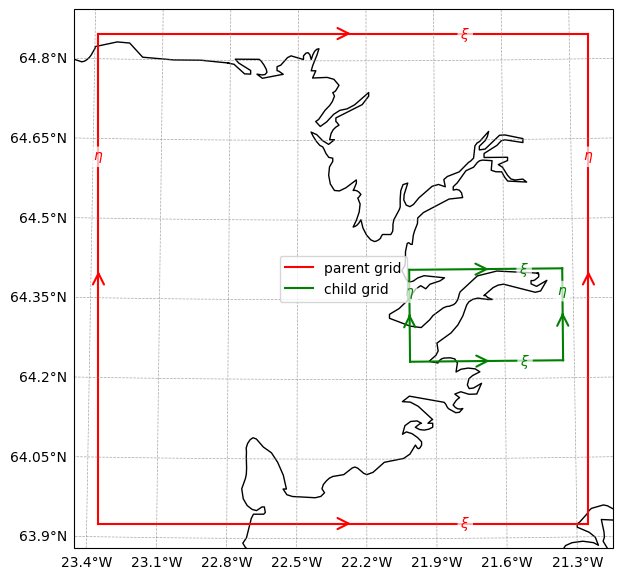

In [8]:
child_grid.plot_nesting(with_dim_names=True)

In [13]:
for v in child_grid.ds_nesting.variables:
    if "temp" in (child_grid.ds_nesting[v].output_vars):
        child_grid.ds_nesting[v].attrs["output_vars"] = child_grid.ds_nesting[v].attrs["output_vars"] + ", bgc"

## Step 5: Child Grid Creation

Builds and writes the child grid file.

In [14]:
filepath = project+child_name+"_grid.nc"
child_grid.save(filepath=filepath)

2026-02-24 12:29:23 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland3_grid.nc


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland3_grid.nc')]

In [15]:
filepath_nesting = project+child_name+"_edata_UPDATED_2.nc"

In [14]:
filepath_nesting

'/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland3_edata_UPDATED.nc'

In [16]:
child_grid.save_nesting(filepath=filepath_nesting)

2026-02-24 12:29:23 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland3_edata_UPDATED_2.nc


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland3_edata_UPDATED_2.nc')]

In [ ]:
import xarray as xr

In [ ]:
from roms_tools import RiverForcing, Grid

In [ ]:
from datetime import datetime

In [ ]:
riv0=xr.open_dataset('/anvil/projects/x-ees250129/Datasets/Iceland_river_dataset/Hvalfjordur_rivers_2023.nc')

In [ ]:
riv0['time']=[202401., 202402., 202403., 202404., 202405., 202406., 202407., 202408.,
       202409., 202410., 202411., 202412.]

## Step 6: River Forcing Modification Output

Writes a modified river forcing NetCDF file.

In [ ]:
riv0.to_netcdf('/anvil/projects/x-ees250129/Datasets/Iceland_river_dataset/Hvalfjordur_rivers_2024.nc')

In [ ]:
start_time = datetime(2024, 1, 1)
end_time = datetime(2024, 12, 31)

In [ ]:
river_forcing = RiverForcing(
    grid=grid,
    start_time=start_time,
    end_time=end_time,
    model_reference_date=datetime(2000, 1, 1), # this is the default
    include_bgc=True,
    source = {
    "name": "DAI",
    "path": "/anvil/projects/x-ees250129/Datasets/Iceland_river_dataset/Hvalfjordur_rivers_2024.nc",
    "climatology": False
}
    
)

In [ ]:
river_forcing.ds

In [ ]:
river_forcing.plot_locations()

In [ ]:
river_forcing.plot("river_volume")

In [ ]:
filepath = project+model_name+"_rivers.nc"

## Step 7: River Forcing Creation

Builds and writes the river forcing file.

In [ ]:
river_forcing.save(filepath=filepath)

Making some customizations to the river forcing (we have observed values of alk and DIC in the rivers and we also know the water is not going to be 17 degrees warm!). We add nutrients (observed values in fjord before spring bloom) and we add observed riverine values of Alk and DIC. These should be subject to change.

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
riv=xr.open_dataset(filepath)
riv.load()

In [ ]:
# Create new array
new_tracer = np.zeros_like(riv['river_tracer'].values)

# Temperature varies sinusoidally with time
temp = 10 * np.sin(np.linspace(0, np.pi, riv.dims['river_time']))  # 12-month cycle

# Loop through tracers
for i, tracer in enumerate(riv['tracer_name'].values):
    if tracer == 'temp':
        new_tracer[:, i, :] = temp[:, np.newaxis]  # vary with time
    elif tracer == 'salt':
        new_tracer[:, i, :] = 1
    elif tracer == 'PO4':
        new_tracer[:, i, :] = 0.4
    elif tracer == 'NO3':
        new_tracer[:, i, :] = 6
    elif tracer == 'SiO3':
        new_tracer[:, i, :] = 3
    elif tracer == 'NH4':
        new_tracer[:, i, :] = 0.4
    elif tracer == 'Fe':
        new_tracer[:, i, :] = 0.000197
    elif tracer == 'Lig':
        new_tracer[:, i, :] = 0.000465    
    elif tracer == 'O2':
        new_tracer[:, i, :] = 360    
    elif tracer == 'DIC':
        new_tracer[:, i, :] = 313    
    elif tracer == 'DIC_ALT_CO2':
        new_tracer[:, i, :] = 313  
    elif tracer == 'ALK':
        new_tracer[:, i, :] = 282 
    elif tracer == 'ALK_ALT_CO2':
        new_tracer[:, i, :] = 282 
    else:
        new_tracer[:, i, :] = 0.0
riv['river_tracer'] = (riv['river_tracer'].dims, new_tracer)

In [ ]:
plt.plot(temp)

## Step 8: River Forcing Modification Output

Writes a modified river forcing NetCDF file.

In [ ]:
riv.to_netcdf(project+model_name+"_rivers_modified.nc")

In [ ]:
import xarray as xr

# Open your modified file
river = xr.open_dataset(project+model_name+"_rivers_modified.nc")
river.load()
# Show what tracers exist
river['river_tracer'].isel(ntracers=10).isel(nriver=6).plot()



Now, we make another river forcing file with half as much volume

In [ ]:
riv['river_volume'][:] = riv['river_volume'].isel(river_time=7)*0.6

In [ ]:
winter_months = [1, 2, 3, 4, 11, 12]

# Create a boolean mask for winter times
winter_mask = riv['abs_time'].dt.month.isin(winter_months)

# Set river_volume to zero where the mask is True
riv['river_volume'] = riv['river_volume'].where(~winter_mask, 0.0)

In [ ]:
riv

## Step 9: River Forcing Modification Output

Writes a modified river forcing NetCDF file.

In [ ]:
riv.to_netcdf(project+model_name+"_rivers_modified_new40off.nc")

In [ ]:
import xarray as xr

# Open your modified file
river1 = xr.open_dataset(project+model_name+"_rivers_modified_new40off.nc")
river1.load()
# Show what tracers exist
river1['river_volume'].isel(nriver=3).plot()


In [ ]:
river1['river_volume'].isel(nriver=6)